target distribution
target
1    59695
0     5671
Name: count, dtype: int64
target
1    0.913
0    0.087
Name: proportion, dtype: float64

shape after dropping cols: (65366, 131)

language grouped:
language_grouped
Other/Unknown    65366
Name: count, dtype: int64

race grouped:
race_grouped
White            43094
Other/Unknown    11924
Black             6016
Hispanic          2351
Asian             1981
Name: count, dtype: int64

missing percentage (columns with any missing):
thrombin_max                    0.999
thrombin_min                    0.999
ggt_min                         0.998
ggt_max                         0.998
globulin_max                    0.998
                                ...  
sofa2_coagulation_24h_max       0.000
sofa2_cardiovascular_24h_max    0.000
sofa2_respiration_24h_max       0.000
sofa2_renal_24h_max             0.000
sofa2_cns_24h_max               0.000
Length: 125, dtype: float64

dropping cols with >50% missing: ['thrombin_max', 'thrombin_min', 'ggt_mi

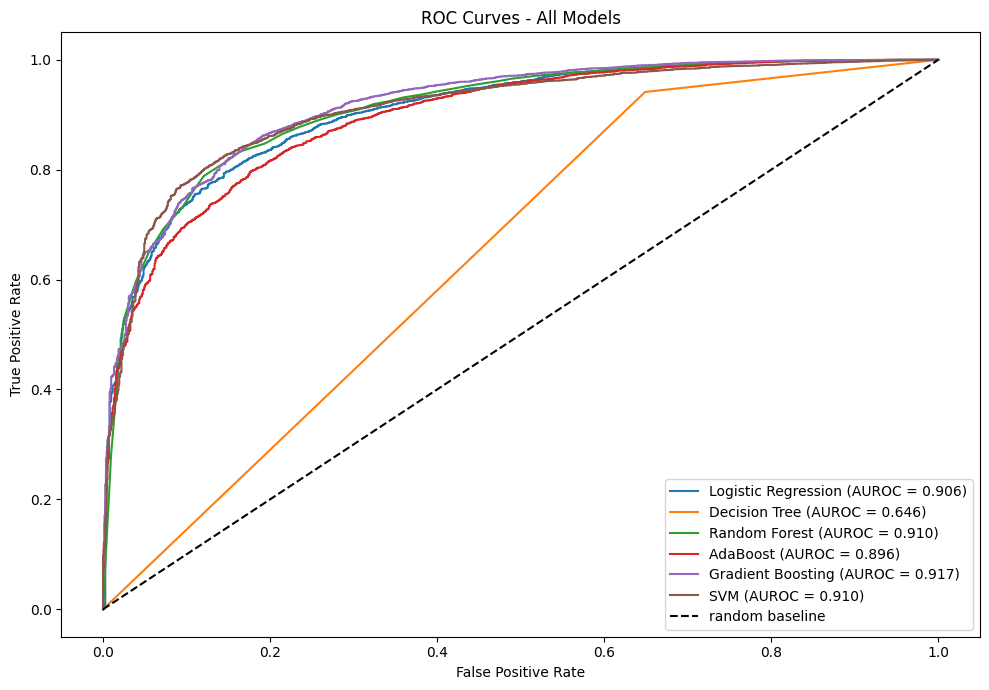

saved roc_curves.png


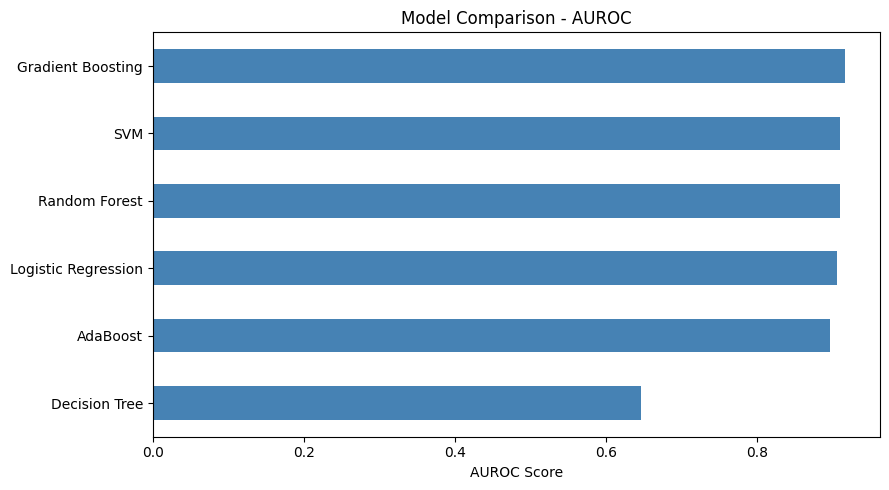

saved model_comparison_auroc.png

top 15 features by RF importance:
resp_rate_mean      0.0600
gcs_motor           0.0588
sbp_min             0.0517
gcs_verbal          0.0511
gcs_eyes            0.0469
spo2_min            0.0420
mbp_min             0.0368
sbp_mean            0.0365
spo2_mean           0.0364
glucose_mean        0.0309
heart_rate_mean     0.0295
temperature_mean    0.0294
heart_rate_max      0.0289
glucose_min         0.0275
mbp_mean            0.0270
dtype: float64


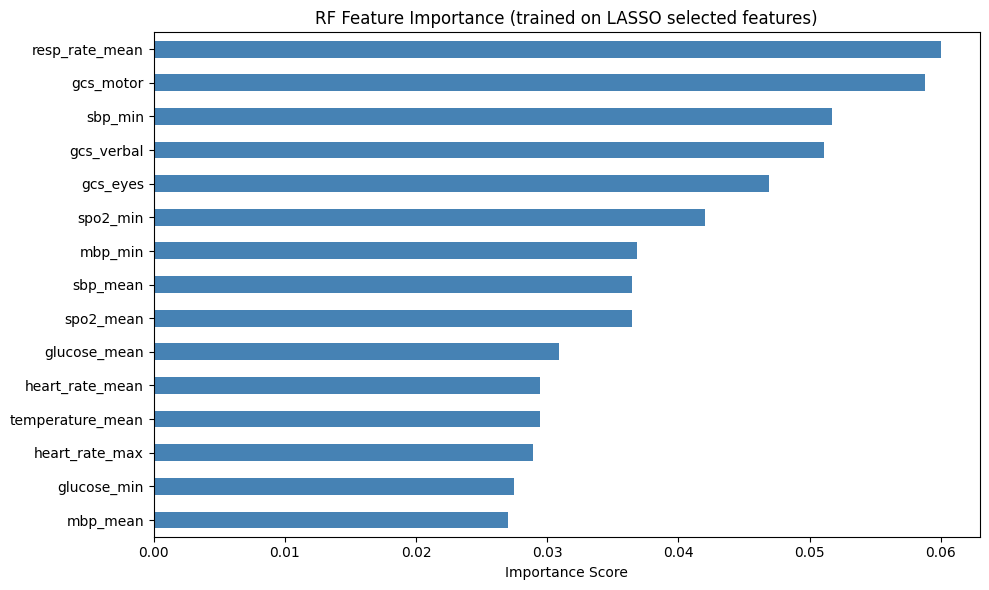

saved rf_feature_importance.png

all done
output files: roc_curves.png, model_comparison_auroc.png, rf_feature_importance.png


In [7]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_score, recall_score,
                             classification_report, roc_curve)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#not the real file used by me (only sample showing the link)
df = pd.read_csv('Assignment1_mimic dataset.csv')

# PHASE 1 - DATA PREPARATION

df['target'] = (df['icu_death_flag'] == 0).astype(int)

print("target distribution")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))

cols_to_drop = [
    'subject_id', 'hadm_id', 'stay_id',
    'intime', 'outtime',
    'los',
    'deathtime',
    'icu_death_flag',
    'hospital_expire_flag',
    'last_careunit',
]
df = df.drop(columns=cols_to_drop)
print("\nshape after dropping cols:", df.shape)

df['language_grouped'] = np.where(
    df['language'] == 'ENGLISH', 'English', 'Other/Unknown'
)
df = df.drop(columns=['language'])
print("\nlanguage grouped:")
print(df['language_grouped'].value_counts())

def group_race(race_str):
    if pd.isna(race_str):
        return 'Other/Unknown'
    race_str = str(race_str).upper()
    if 'WHITE' in race_str or 'PORTUGUESE' in race_str:
        return 'White'
    elif 'BLACK' in race_str or 'AFRICAN' in race_str:
        return 'Black'
    elif 'ASIAN' in race_str:
        return 'Asian'
    elif 'HISPANIC' in race_str or 'LATINO' in race_str or 'SOUTH AMERICAN' in race_str:
        return 'Hispanic'
    else:
        return 'Other/Unknown'

df['race_grouped'] = df['race'].apply(group_race)
df = df.drop(columns=['race'])
print("\nrace grouped:")
print(df['race_grouped'].value_counts())

missing_pct = df.isnull().mean().sort_values(ascending=False)
print("\nmissing percentage (columns with any missing):")
print(missing_pct[missing_pct > 0].round(3))

high_missing = missing_pct[missing_pct > 0.5].index.tolist()
print("\ndropping cols with >50% missing:", high_missing)
df = df.drop(columns=high_missing)
print("shape after dropping high missing cols:", df.shape)

cat_cols = ['first_careunit', 'insurance', 'language_grouped',
            'race_grouped', 'marital_status', 'gender']
cat_cols = [c for c in cat_cols if c in df.columns]
print("\ncategorical cols:", cat_cols)

num_cols = [c for c in df.columns if c not in cat_cols + ['target']]
print("numeric cols:", len(num_cols))

cat_imp = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imp.fit_transform(df[cat_cols])

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("shape after encoding:", df.shape)


# PHASE 2 - TRAIN TEST SPLIT


X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\ntrain size:", X_train.shape)
print("test size:", X_test.shape)
print("train target balance:", round(y_train.mean(), 3))
print("test target balance:", round(y_test.mean(), 3))


# PHASE 3 - NUMERIC IMPUTATION (fit on train only)


num_cols_now = X_train.select_dtypes(include=np.number).columns.tolist()

low_miss = [c for c in num_cols_now if X_train[c].isnull().mean() < 0.05]
mid_miss = [c for c in num_cols_now if 0.05 <= X_train[c].isnull().mean() <= 0.5]

print("\nlow missing cols (<5%):", len(low_miss))
print("mid missing cols (5-50%):", len(mid_miss))


mean_imp = SimpleImputer(strategy='mean')

if low_miss:
    X_train[low_miss] = mean_imp.fit_transform(X_train[low_miss])
    X_test[low_miss]  = mean_imp.transform(X_test[low_miss])

median_imp = SimpleImputer(strategy='median')

if mid_miss:
    X_train[mid_miss] = median_imp.fit_transform(X_train[mid_miss])
    X_test[mid_miss]  = median_imp.transform(X_test[mid_miss])

print("missing in X_train after imputation:", X_train.isnull().sum().sum())
print("missing in X_test after imputation:", X_test.isnull().sum().sum())


# PHASE 4 - SCALING (fit on train only)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("\nscaling done")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)


# PHASE 5 - FEATURE SELECTION USING LASSO


print("\n--- LASSO feature selection ---")

lasso = LogisticRegressionCV(
    penalty='l1',
    solver='liblinear',
    cv=5,
    class_weight='balanced',
    random_state=42,
    max_iter=10000
)
lasso.fit(X_train_scaled, y_train)

lasso_selected = X_train_scaled.columns[lasso.coef_[0] != 0].tolist()

print("features before LASSO:", X_train_scaled.shape[1])
print("features after LASSO:", len(lasso_selected))
print("features removed:", X_train_scaled.shape[1] - len(lasso_selected))
print("dimension reduction:", round((1 - len(lasso_selected)/X_train_scaled.shape[1])*100, 1), "%")
print("\nselected features:", lasso_selected)


X_train_sel = X_train_scaled[lasso_selected]
X_test_sel  = X_test_scaled[lasso_selected]

print("\nfinal train set:", X_train_sel.shape)
print("final test set:", X_test_sel.shape)



# PHASE 6 - TRAIN AND COMPARE ALL MODELS

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=10000
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),
    'SVM': SVC(
        class_weight='balanced',
        probability=True,
        random_state=42
    )
}

results = {}
roc_data = {}
trained_models = {}

print("\n=== model training and evaluation ===")

for name, model in models.items():
    model.fit(X_train_sel, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test_sel)
    y_prob = model.predict_proba(X_test_sel)[:, 1]

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'F1':        round(f1_score(y_test, y_pred), 3),
        'AUROC':     round(roc_auc_score(y_test, y_prob), 3)
    }

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, results[name]['AUROC'])

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).T.sort_values('AUROC', ascending=False)
print("\n=== summary table (sorted by AUROC) ===")
print(results_df)


# PHASE 7 - VISUALISATIONS

plt.figure(figsize=(10, 7))
for name, (fpr, tpr, auroc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUROC = {auroc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("saved roc_curves.png")


plt.figure(figsize=(9, 5))
results_df['AUROC'].sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('AUROC Score')
plt.title('Model Comparison - AUROC')
plt.tight_layout()
plt.savefig('model_comparison_auroc.png', dpi=150)
plt.show()
print("saved model_comparison_auroc.png")


rf_model = trained_models['Random Forest']

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X_train_sel.columns
).sort_values(ascending=False)

print("\ntop 15 features by RF importance:")
print(feat_imp.head(15).round(4))

plt.figure(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('RF Feature Importance (trained on LASSO selected features)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()
print("saved rf_feature_importance.png")

print("\nall done")
print("output files: roc_curves.png, model_comparison_auroc.png, rf_feature_importance.png")

In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.39      0.76      0.51      1134
           1       0.97      0.89      0.93     11940

    accuracy                           0.88     13074
   macro avg       0.68      0.82      0.72     13074
weighted avg       0.92      0.88      0.89     13074



In [13]:
y_prob_death = trained_models['Gradient Boosting'].predict_proba(X_test_sel)[:,0]

from sklearn.metrics import average_precision_score

auprc_death = average_precision_score(
    (y_test == 0).astype(int),
    y_prob_death
)

print("AUPRC (Death):", auprc_death)

AUPRC (Death): 0.6236590536740382


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.39      0.76      0.51      1134
           1       0.97      0.89      0.93     11940

    accuracy                           0.88     13074
   macro avg       0.68      0.82      0.72     13074
weighted avg       0.92      0.88      0.89     13074

[[  862   272]
 [ 1353 10587]]


In [17]:
print(feat_imp.head(10))

resp_rate_mean    0.059985
gcs_motor         0.058780
sbp_min           0.051711
gcs_verbal        0.051074
gcs_eyes          0.046897
spo2_min          0.042043
mbp_min           0.036822
sbp_mean          0.036480
spo2_mean         0.036444
glucose_mean      0.030894
dtype: float64


AUPRC (Death): 0.6236590536740382


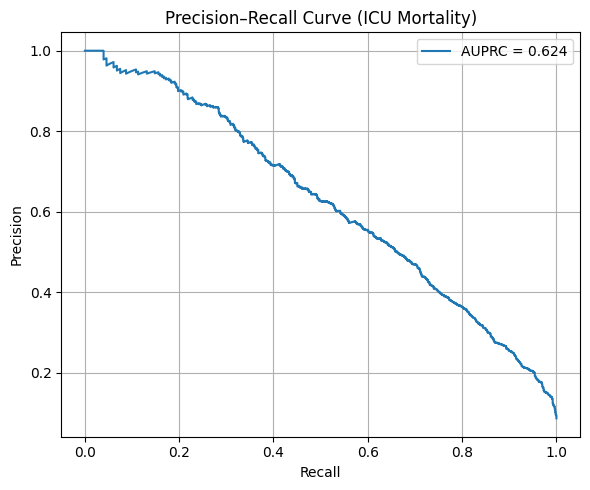

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_prob_death = trained_models['Gradient Boosting'].predict_proba(X_test_sel)[:, 0]

y_test_death = (y_test == 0).astype(int)

precision, recall, thresholds = precision_recall_curve(
    y_test_death,
    y_prob_death
)

auprc = average_precision_score(y_test_death, y_prob_death)
print("AUPRC (Death):", auprc)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (ICU Mortality)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pr_curve_death.png", dpi=300)
plt.show()